## 0.3 복소수

복소수 사칙연산·켤레·절댓값·오일러 공식을 확인하고, 전역 위상과 상대 위상의 차이를 시뮬레이션한다.

In [ ]:
%pip install -q koreanize-matplotlib

### 0.3.1 허수단위와 복소수 (파이썬은 `j`가 허수단위)

In [1]:
z = 3 + 2j; w = 5 + 4j
print("z+w =", z+w, ", z*w =", z*w, ", i^2 =", 1j**2)

z+w = (8+6j) , z*w = (7+22j) , i^2 = (-1+0j)


### 0.3.2 켤레복소수와 절댓값

In [2]:
import numpy as np

z = 3 + 2j
print("켤레 z* =", z.conjugate(), ", |z| =", abs(z), ", |z|^2 =", abs(z)**2)
print("z·z* =", z*z.conjugate())   # 실수 = |z|^2
assert np.isclose((z*z.conjugate()).real, abs(z)**2)
print("검증 통과: z·z* = |z|²")

켤레 z* = (3-2j) , |z| = 3.605551275463989 , |z|^2 = 12.999999999999998
z·z* = (13+0j)
검증 통과: z·z* = |z|²


### 0.3.3 오일러 공식과 위상

In [3]:
import numpy as np

theta = np.pi/3
assert np.isclose(np.exp(1j*theta), np.cos(theta)+1j*np.sin(theta))
print("오일러 공식 검증 통과: e^{iθ} = cosθ + i sinθ")

오일러 공식 검증 통과: e^{iθ} = cosθ + i sinθ


### 0.3.4 심화: 전역 위상과 상대 위상
전역 위상은 측정에 영향이 없지만, 두 성분의 상대 위상은 간섭을 통해 결과를 바꾼다.

In [4]:
import numpy as np

# 전역 위상: |psi>와 e^{iγ}|psi> 의 측정 확률은 동일
psi = np.array([1, 1j])/np.sqrt(2)
gamma = 1.2
psi_g = np.exp(1j*gamma)*psi
print("원래 확률   :", np.round(np.abs(psi)**2, 4))
print("전역위상 후 :", np.round(np.abs(psi_g)**2, 4))
print("동일?", np.allclose(np.abs(psi)**2, np.abs(psi_g)**2))

원래 확률   : [0.5 0.5]
전역위상 후 : [0.5 0.5]
동일? True


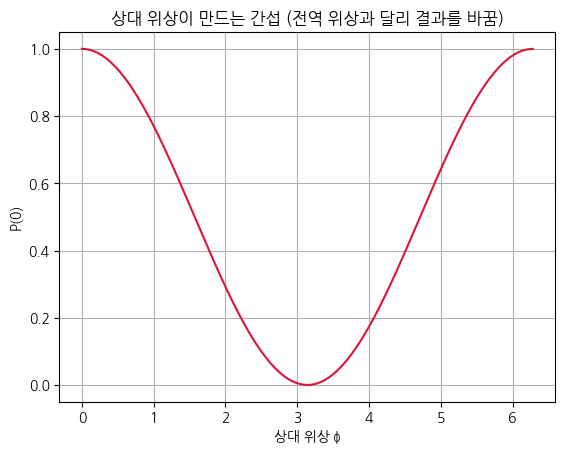

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
%matplotlib inline

# 상대 위상 φ에 따른 간섭: ψ = (|0> + e^{iφ}|1>)/√2 를 H로 간섭시킨 결과
phis = np.linspace(0, 2*np.pi, 200)
H = (1/np.sqrt(2))*np.array([[1,1],[1,-1]])
P0 = []
for phi in phis:
    psi = np.array([1, np.exp(1j*phi)])/np.sqrt(2)
    out = H @ psi
    P0.append(abs(out[0])**2)
plt.plot(phis, P0, color='crimson')
plt.xlabel("상대 위상 φ"); plt.ylabel("P(0)")
plt.title("상대 위상이 만드는 간섭 (전역 위상과 달리 결과를 바꿈)")
plt.grid(True); plt.show()